# Proyecto UD4
#### UD4. Redes Neuronais
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo),Vanesa Resúa Eiras, Cristina Gómez Alonso


### Datasets de Clasificación: Cristales vs Crédito

Para este proyecto os doy opción a que escojáis entre dos datasets diferentes.
El primero no os exigirá ningún preprocesado previo, mientras que el segundo sí.
Por otro lado, el primero es clasificación multiclase, mientras que el segundo es de clasificación binaria.
La calificación máxima en caso de que escojáis el primero será de 8 puntos mientras que si escojéis el segundo será de 10 puntos.

#### Dataset Crédito

Disponemos de un dataset con 1000 instancias clasificadas en 2 tipos diferentes de clientes: a los que se les otorga un crédito y a los que no.

Lista de atributos para cada entrada será:

* checking_status: estado de la cuenta corriente existente, en marcos alemanes.
* duration: duración en meses
* credit_history: historial crediticio (créditos tomados, reembolsados debidamente, atrasos, cuentas críticas)
* purpose: finalidad del crédito (coche, televisión,…)
* credit_amount: cantidad solicitada de crédito
* saving_status: estado de su cuenta de ahorro/bonos, en marcos alemanes.
* employment: empleo actual en número de años.
* installament_commitment: tasa de cuota en porcentaje de ingresos disponibles
* personal_status: estado personal (casado, soltero,…) y sexo
* other_parties: otros deudores / garantes
* residence_since: residencia actual desde hace X años
* property_magnitude: propiedades (por ejemplo, casas, pisos...)
* age: Edad en años
* other_payment_plans: otros planes de cuotas (bancos, tiendas)
* housing: vivienda (alquiler, propia,…)
* existing_credits: número de créditos existentes con esta entidad
* job: trabajo
* num_dependents: número de personas dependientes o a las que proporcionan manuntención
* own_phone: teléfono (yes, no)
* foreign_worker: trabajador extranjero (yes, no)
* class: clase: good (crédito otorgado), bad (crédito denegado)

Escoge uno de los dos datasets anteriores y resuelve los siguientes apartados.

## 1. Importación del dataset

In [30]:
import math
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [20]:
creditos = pd.read_csv('credits.csv')
creditos

,ID,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,vty,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,dkl,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,bwf,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,qln,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,uzh,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,jlf,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,imr,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,...,life insurance,140,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,xnt,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,...,car,38,none,own,1,skilled,1,none,yes,good
998,egn,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


## 2. EDA&Preprocessing (2 puntos crédito, 1 punto cristales)

In [23]:
print(f"Nuestro dataframe tiene {creditos.shape[0]} filas y {creditos.shape[1]} columnas")


Nuestro dataframe tiene 1000 filas y 22 columnas


In [28]:
creditos.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.746000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,12.367961,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,149.000000,4.000000,2.000000


In [24]:
creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ID                      999 non-null    object
 1   checking_status         1000 non-null   object
 2   duration                1000 non-null   int64 
 3   credit_history          1000 non-null   object
 4   purpose                 1000 non-null   object
 5   credit_amount           1000 non-null   int64 
 6   savings_status          1000 non-null   object
 7   employment              1000 non-null   object
 8   installment_commitment  1000 non-null   int64 
 9   personal_status         1000 non-null   object
 10  other_parties           1000 non-null   object
 11  residence_since         1000 non-null   int64 
 12  property_magnitude      1000 non-null   object
 13  age                     1000 non-null   int64 
 14  other_payment_plans     1000 non-null   object
 15  housi

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
El dataset cuenta con un total de <strong>21 columnas</strong>. Podemos ver que tenemos información incompleta en algunas de ellas, concretamente en <code>id</code> y <code>own_telephone</code>.
</p>

<p>
Además, se observa presencia de variables categóricas (tipo <code>object</code>), las cuales será necesario transformar.
</p>

</div>

In [25]:
print(f"Valores duplicados: {creditos.duplicated().sum()}")

Valores duplicados: 0


In [26]:
creditos.isnull().sum()

ID                         1
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment                 0
installment_commitment     0
personal_status            0
other_parties              0
residence_since            0
property_magnitude         0
age                        0
other_payment_plans        0
housing                    0
existing_credits           0
job                        0
num_dependents             0
own_telephone             10
foreign_worker             0
class                      0
dtype: int64

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
Se observa la presencia de valores nulos en dos columnas.
</p>

<ul>
    <li>La columna <code>id</code> presenta <strong>1 valor nulo</strong>.</li>
    <li>La columna <code>own_telephone</code> contiene <strong>10 valores nulos</strong>.</li>
</ul>

<p>
Aunque la cantidad de valores faltantes es reducida, será importante tenerlos en cuenta...
</p>

</div>

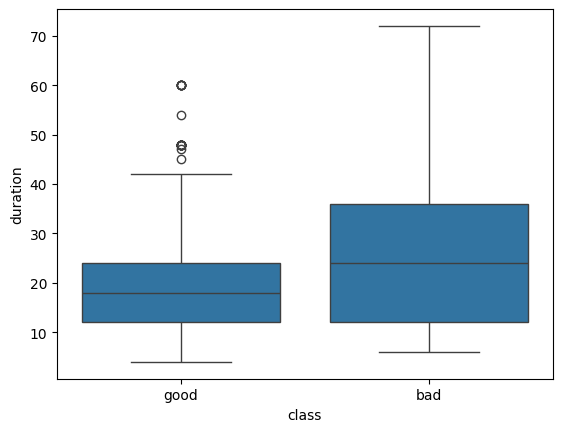

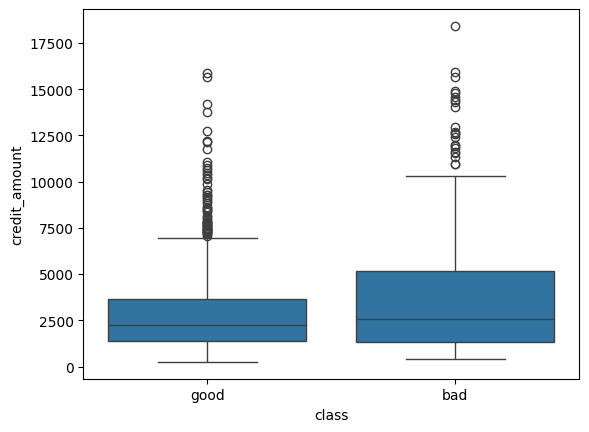

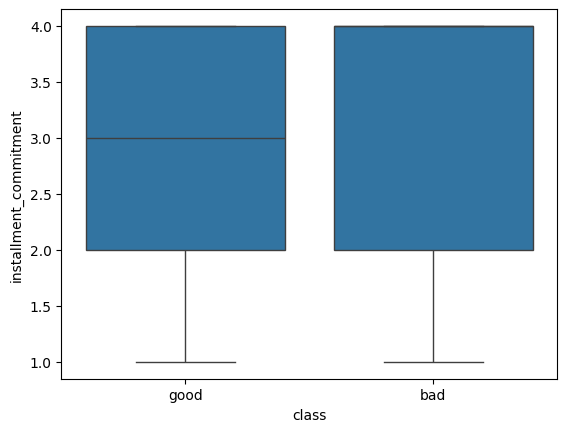

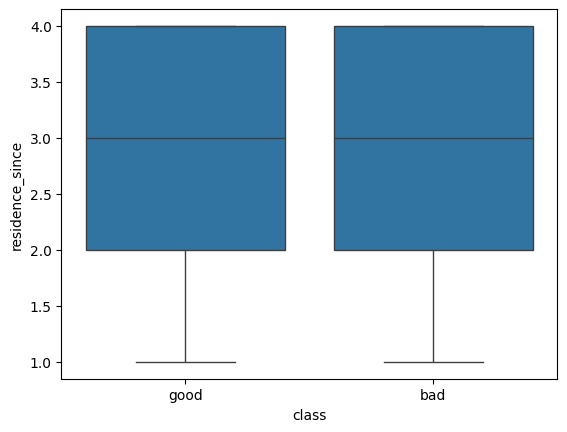

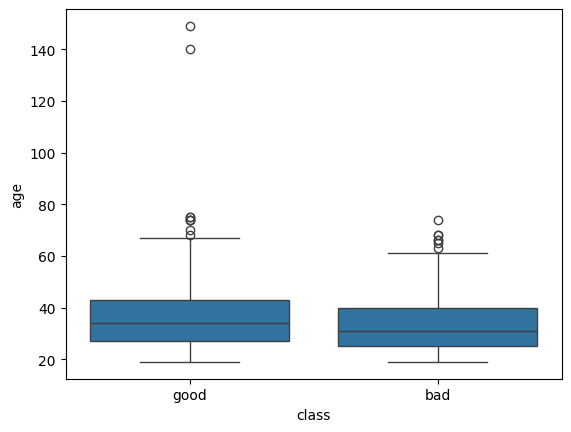

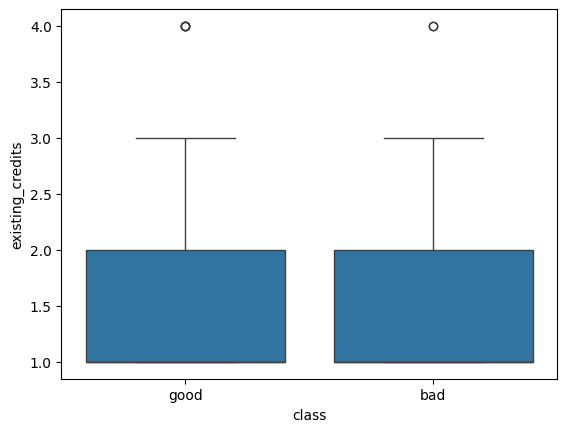

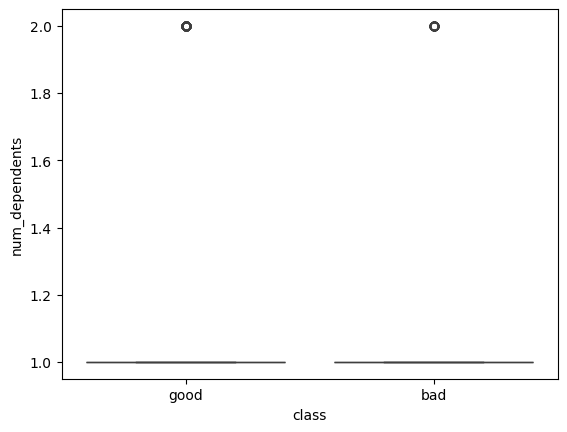

In [ ]:
num_cols = creditos.select_dtypes(include=['int64', 'float64']).columns

for var in num_cols:
    sns.boxplot(x='class', y=var, data=creditos)
    plt.show()

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
Al examinar los boxplots en relación con la variable objetivo (<code>class</code>), se aprecia que algunas variables tienen un peso notable en la evaluación del riesgo. En particular, la duración del préstamo y el importe solicitado destacan: los préstamos más largos y de mayor cuantía se asocian con la categoría <strong>'bad'</strong>.
</p>

<p>
Asimismo, se observa una ligera tendencia a una mayor tasa de morosidad entre los clientes de menor edad en comparación con los de mayor edad.
</p>

<p>
Por otro lado, varias variables las económicas y la edad presentan valores atípicos significativos por ejemplo alguien de 150 años, es imposible... Esta situación hace recomendable aplicar técnicas de estandarización, como <code>StandardScaler</code>
</p>

</div>

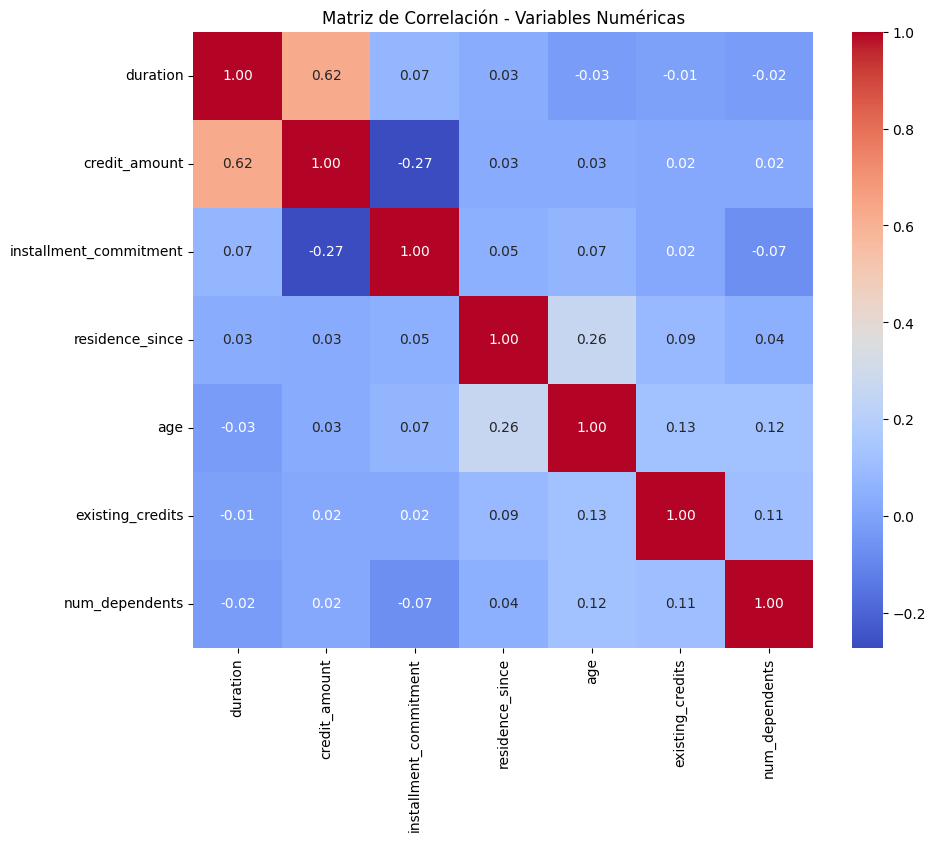

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(creditos[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
La relación más destacada del dataset es la correlación positiva entre <code>duration</code> y <code>credit_amount</code> (0.62). Esto indica que los préstamos de mayor importe suelen ir acompañados de plazos más largos, algo coherente desde el punto de vista financiero.
</p>

<p>
También se observa una correlación negativa moderada entre <code>credit_amount</code> e <code>installment_commitment</code> (-0.27). Esto sugiere que, cuando el importe del préstamo es elevado, las entidades tienden a ajustar el plazo para reducir el peso de la cuota mensual sobre los ingresos del cliente.
</p>

<p>
Por último, a nivel demográfico, existe una ligera correlación positiva entre <code>age</code> y <code>residence_since</code> (0.26), lo que refleja que los clientes de mayor edad suelen tener una mayor estabilidad residencial.
</p>

</div>

In [ ]:
# Realiza un análisis exploratorio de los datos. ¿Puedes extraer alguna información? ¿Hay valores duplicados? ¿Hay outliers? ¿Existen features correlacionadas entre sí?
# Realiza un preprocesado de los datos antes de pasar el siguiente apartado

## 3. Creación RRNN, entrenamientos, evaluaciones, predicciones y representación gráfica (4 puntos crédito, 3 puntos cristales)

In [ ]:
# Crea dos modelos de redes neuronales densamente conectada. Entrena ambos con el 80% de los datos y evalúa su resultado con el 20% de testing. ¿Qué conclusiones extraemos? ¿Cuántos parámetros necesitará crear cada una de tus RRNN? ¿Qué número de epochs consideras más adecuado para tu dataset? ¿Por qué?
# Comentario: explica detallamente lo que haces al crear cada una de las capas de tu red y porque escoges los hiperparámetros que has decidido aplicar.

## 4. Selección de otro modelo de aprendizaje supervisado (2 puntos)

In [ ]:
# Crea otro modelo de aprendizaje supervisado, entrénalo y evalúa sus resultados. ¿Qué resultados obtienes? Justifica tu respuesta.

## 5. Análisis comparativo y Conclusiones (2 puntos)

In [ ]:
# Contrasta tus redes neuronales densamente conectada con tu modelo de aprendizaje supervisado clásico. ¿Con cuál te quedas? ¿Qué motivos crees que han condicionado tus resultados? ¿Estás satisfecho? ¿Tienes alguna propuesta de mejora? Justifica tus respuestas